## Processador de Entrada (Fuzzificação)

In [1]:
# Bibliotecas
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

from skfuzzy import control as ctrl

### Antecedente

In [6]:
# Variáveis fuzzy
# Antecedentes (inputs)
AoL = ctrl.Antecedent(np.arange(23, 58, 0.001), 'AoL') # cm²
EgL = ctrl.Antecedent(np.arange(0, 3.32, 0.001), 'EgL') # mm

In [7]:
# Funções de pertinência dos antecedentes Trapezoidal
# Aqui precisa do especialista para definir os valores de cada função de pertinência
""" Só um teste """
AoL['Pequeno'] = fuzz.trapmf(AoL.universe, [0,0,25,33.75])
AoL['Médio'] = fuzz.trapmf(AoL.universe, [25,33.75,42.5,51.25])
AoL['Grande'] = fuzz.trapmf(AoL.universe, [42.5,51.25,58,58])

EgL['Pequeno'] = fuzz.trapmf(EgL.universe, [0,0,0.83,1.45])
EgL['Médio'] = fuzz.trapmf(EgL.universe, [0.83,1.45,2.075,2.6975])
EgL['Grande'] = fuzz.trapmf(EgL.universe, [2.075,2.6975,3.32,3.32])

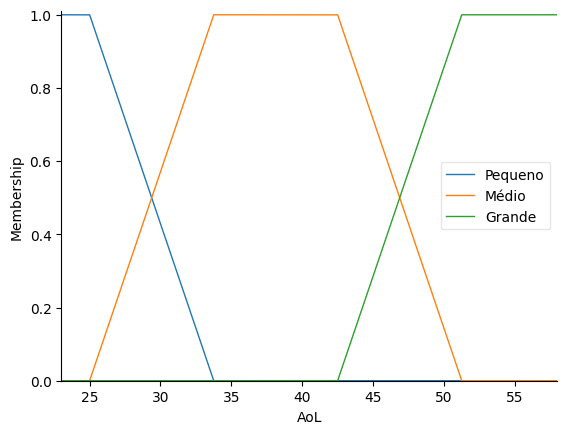

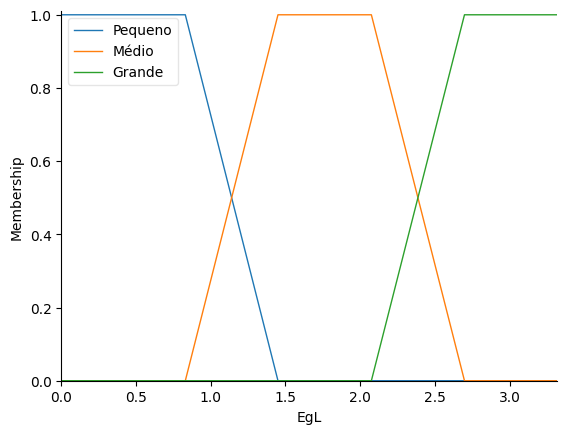

In [8]:
# Plot do gráfico dos antecedentes
AoL.view()
EgL.view()
plt.show()

### Consequente

In [9]:
# Consequente (output) "qualidade do fenótipo do boi" 
# Perguntar para a Amanda.
qualidade = ctrl.Consequent(np.arange(0, 1, 0.001), 'qualidade do fenótipo do boi')

qualidade['Baixo'] = fuzz.trapmf(qualidade.universe, [0,0,0.2,0.4])
qualidade['Regular'] = fuzz.trapmf(qualidade.universe, [0.2,0.4,0.6,0.8])
qualidade['Alto'] = fuzz.trapmf(qualidade.universe, [0.6,0.8,1,1])

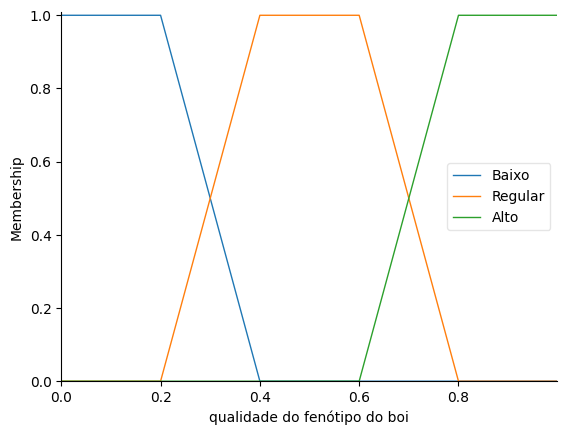

In [10]:
qualidade.view()
plt.show()

## Base de Regras

In [14]:
# Regras de inferência fuzzy
# Precisa do especialista para definir as regras de inferência fuzzy
regra1 = ctrl.Rule(AoL['Pequeno'] & EgL['Pequeno'], qualidade['Baixo'])
regra2 = ctrl.Rule(AoL['Pequeno'] & EgL['Médio'], qualidade['Baixo'])
regra3 = ctrl.Rule(AoL['Pequeno'] & EgL['Grande'], qualidade['Regular'])

regra4 = ctrl.Rule(AoL['Médio'] & EgL['Pequeno'], qualidade['Baixo'])
regra5 = ctrl.Rule(AoL['Médio'] & EgL['Médio'], qualidade['Regular'])
regra6 = ctrl.Rule(AoL['Médio'] & EgL['Grande'], qualidade['Alto'])

regra7 = ctrl.Rule(AoL['Grande'] & EgL['Pequeno'], qualidade['Regular'])
regra8 = ctrl.Rule(AoL['Grande'] & EgL['Médio'], qualidade['Alto'])
regra9 = ctrl.Rule(AoL['Grande'] & EgL['Grande'], qualidade['Alto'])

## Máquina de inferência Fuzzy e Defuzzificação

In [15]:
# O métido utilizado para a Inferência é o método de Mamdani
sistema = ctrl.ControlSystem([regra1, regra2, regra3, regra4, regra5, regra6, regra7, regra8, regra9])
# O método utilizado para a defuzzificação é o método do Centro de Gravidade (Centroid)
# G(C) = (\sum^n_{i=0}z_i * C(z_i)) / (\sum^n_{i=0}C(z_i))
simulacao = ctrl.ControlSystemSimulation(sistema)

### Testando o SBRF

0.55857960248141


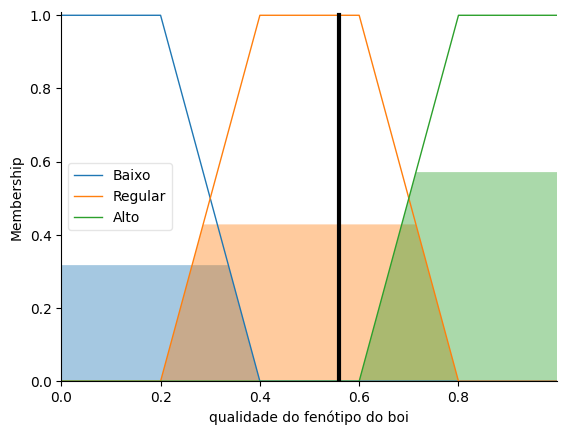

In [16]:
simulacao.input['AoL'] = 30
simulacao.input['EgL'] = 2.5
simulacao.compute()
print(simulacao.output['qualidade do fenótipo do boi'])
qualidade.view(simulacao)
plt.show()

## Testes fuzzy

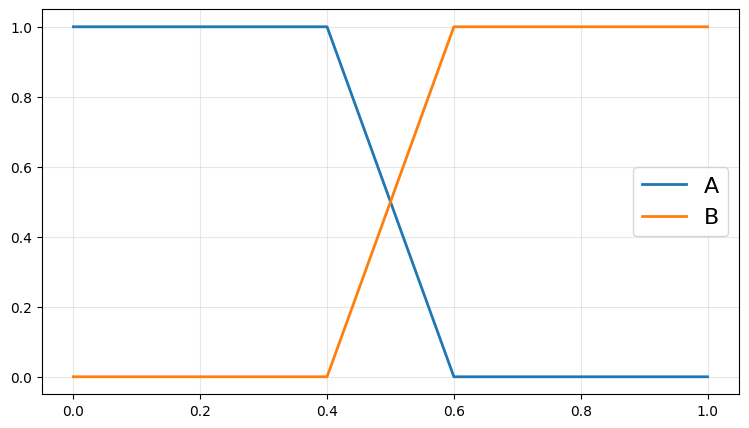

In [16]:
graf= ctrl.Antecedent(np.arange(0, 1.001, 0.01), 'graf') 

""" Só um teste """
graf['A'] = fuzz.trapmf(graf.universe, [0,0,0.4,0.6])
graf['B'] = fuzz.trapmf(graf.universe, [0.4,0.6,1,1])

x = graf.universe
A = graf['A'].mf
B = graf['B'].mf

uniao = np.fmax(A, B)         # A U B
intersec = np.fmin(A, B)      # A ∩ B
comp_A = 1 - A                # complementar de A
comp_B = 1 - B                # complementar de B

plt.figure(figsize=(9,5))
plt.plot(x, A, label='A', linewidth=2)
plt.plot(x, B, label='B', linewidth=2)
# plt.scatter(x, uniao, label='A U B', linewidth=1)
# plt.scatter(x, intersec,  label='A ∩ B', linewidth=1, color='red')
# plt.scatter(x, comp_A, label=r"A'", linewidth=1, color = 'green')
# plt.plot(x, comp_B, ':', label='¬B', linewidth=2)
# plt.ylim(0, 1.05)
plt.legend(fontsize=16)
plt.grid(alpha=0.3)
plt.savefig('AB.png', dpi=300, bbox_inches='tight')
plt.show()